# Building Docker Images

Please download the `data` directory from the left hand nav.

## Docker Images

A container image created with Docker is called a Docker image. Let's see how we can create a simple image to run a simple bash script.

Docker images are defined in a file called [Dockerfile](https://docs.docker.com/engine/reference/builder/). A basic Dockerfile is provided as an example in the data directory.

```dockerfile
FROM ubuntu:latest

COPY myscript.sh /myscript.sh

RUN chmod +x /myscript.sh

ENTRYPOINT ["/myscript.sh"]
```

Let's break this down: 
- The `FROM` statement indicates a "base" image to use. This is another docker image used as starting point for the dockerfile. 
- Next, the bash script is copied from local machine into the image. 
- The `RUN` statement runs a shell command to mark the script within image as executable. The script on local machine is not modified. 
- `ENTRYPOINT` defines the command to run when executing the image. This command isn't executed during the build. 

To build the image, run the command:

```bash
docker build -t myapp:latest .
```

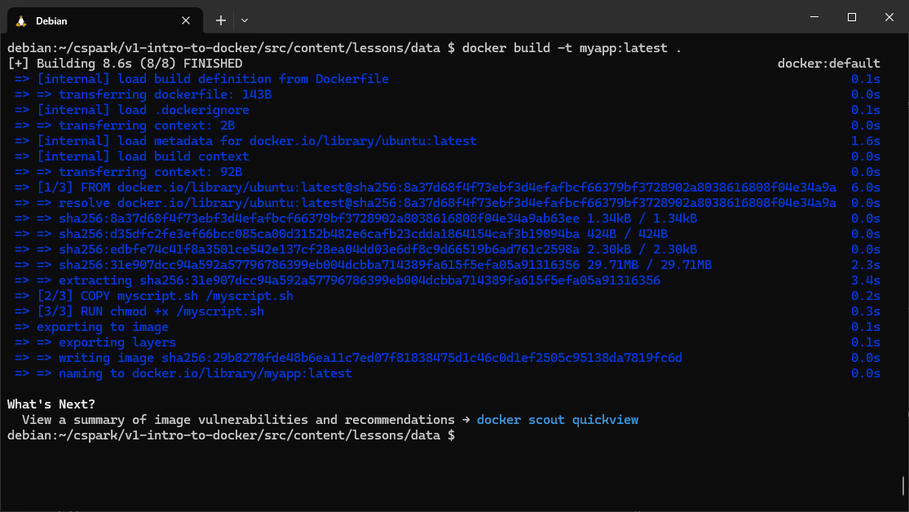

This builds an image called `myapp` with the version tag as `latest` from the file named `Dockerfile` in the current directory (denoted by `.` in bash). It will also store it in the local docker registry. List all your local images and versions by executing the following:

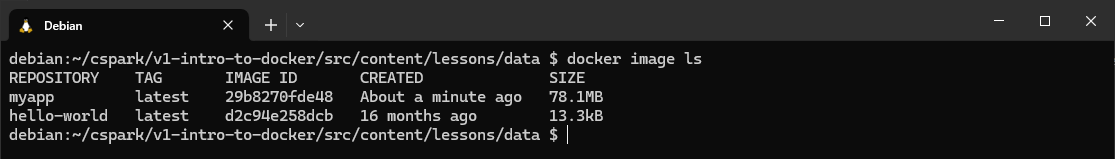

So now that our simple "app" (script) is packaged as a docker container image, let's execute it and create a container.

```bash
$ docker run myapp:latest
Hello from the container
```

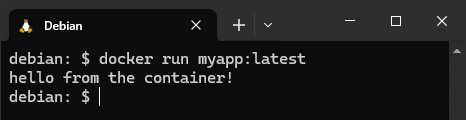

What has happened is that the docker engine has taken the image, created a container, and executed the entrypoint script that is packaged within it. This resulted in the output "Hello from the container". Since the script has stopped running after printing the message, the container exited. We can list all containers running or stopped with:

```bash
$ docker ps -a
CONTAINER ID   IMAGE          COMMAND          CREATED         STATUS                     PORTS     NAMES
dd57b33d60e5   myapp:latest   "/myscript.sh"   4 seconds ago   Exited (0) 3 seconds ago             ecstatic_chebyshev
```

This shows that the image `myapp:latest` executed the command `/myscript.sh` in a container with ID `dd57b33d60e5`. 

### Python Example

Containers can be long running like a service or a short job that starts and exits when completed. In this section, we look at a simple Python web application and how to package and execute it with Docker.

Python application script `app.py` and `requirements.txt` will be used.

Usually when installing this dependency we would create a Python virtual environment. With Docker, this is not necessary as the container is an isolated environment in itself. The dependencies can be installed directly within the container image. For this, the Python community has provided a base image with Python pre-installed. 

File: `python-webapp.Dockerfile`

```dockerfile
FROM python:3.11

RUN mkdir /app

WORKDIR /app

COPY requirements.txt requirements.txt
COPY app.py app.py

RUN pip install -r requirements.txt

ENV FLASK_APP=app FLASK_ENV=development

ENTRYPOINT ["flask"]
CMD ["run", "--host=0.0.0.0"]
```

There are some new commands here, so let's break this down: 
- `WORKDIR` sets the working directory so that all the following commands use that as the current directory for all relative paths in respect to the container. 
- The `COPY` command copies the files into the `/app` directory. 
- `RUN` is used to install requirements once during the build. 
- `ENV` sets environment variables. These can be overwritten when running the container but the defaults are set here. 
- `CMD` is the command arguments to be passed to the `ENTRYPOINT`. In a virtual environment, a flask application would be executed with `flask run --host=0.0.0.0`. In this case `flask` is the entrypoint script and `run --host=0.0.0.0` are the two arguments as commands. 

Execute the docker build and container as before:

```bash
$ docker build -t pythonapp:latest -f python-webapp.Dockerfile .
```

Since we have multiple Dockerfiles in the directory we can specify a specific one to build using the `-f <file>` argument.

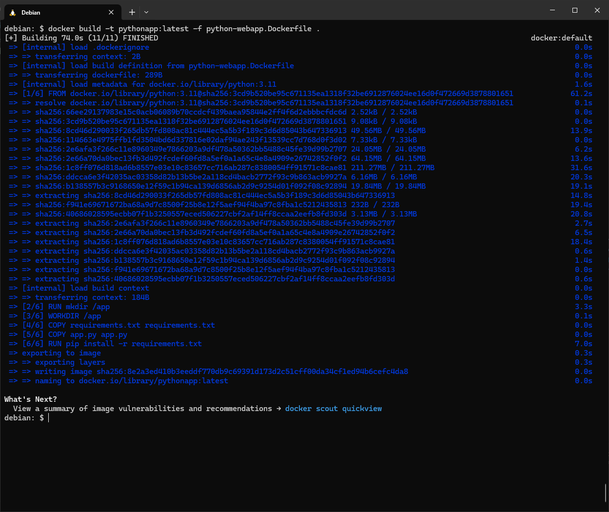

Once successful you can execute this image as follows:

```bash
$ docker run pythonapp:latest
* Serving Flask app 'app'
 * Debug mode: off
WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.17.0.2:5000
Press CTRL+C to quit
```

This is a web server that is accessible on port 5000. In another terminal you can list the running containers to see:

```bash
$ docker ps
CONTAINER ID   IMAGE              COMMAND                  CREATED         STATUS         PORTS     NAMES
bbe63bcb1227   pythonapp:latest   "flask run --host=0.…"   About a minute ago   Up About a minute             busy_blackburn
```

Here's a new concept around networking. The network is also isolated and virtualised in Docker. Docker engine contains a software defined network and the above container is only accessible within that network. The flask service won't be accessible on http://localhost:5000/. For it to be accessible outside Docker, the ports need to be mapped onto the host machine. This can be done through the `-p host:container` arguments.

Stop the container process by pressing Ctrl+C in the terminal where the container is running. Now execute the docker run command with the `-p <ipaddress>:<hostport>:<containerport>` argument. `-p` argument is for publishing or exposing ports from container to host. The IP Address is optional and will make the ports available on all network interfaces. 

```bash
$ docker run -p 5000:5000 pythonapp:latest
* Serving Flask app 'app'
 * Debug mode: off
WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.17.0.2:5000
Press CTRL+C to quit
```

Now this will be accessible on the host machine at http://localhost:5000/

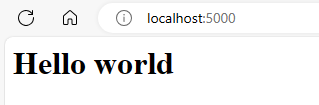

This application is running in the foreground of the terminal. If you exit the terminal, the docker container will stop too. It is possible to run this in the background by using the daemon mode with `-d` flag on the `docker run` command.

```bash
$ docker run -d -p 5000:5000 pythonapp:latest
0f28a77d9c594075ef720b7a9e1aae9549d5bcdcb13bd12f1ffc5c935c0d2a0e
$ docker ps
CONTAINER ID   IMAGE              COMMAND                  CREATED          STATUS          PORTS                    NAMES
0f28a77d9c59   pythonapp:latest   "flask run --host=0.…"   18 seconds ago   Up 17 seconds   0.0.0.0:5000->5000/tcp   youthful_feynman
```

Now Docker is executing the container in the background. It has printed out the container id which can be viewed using `docker ps` again.


## Volumes

Volumes are the mechanism to store data and reuse it across containers. There are two types: Volumes can be managed separately from containers or a "bind mount" can be used as a volume that maps the host's filesytem to the container. 

### Bind Mounts

Bind mounts are managed as part of a container and defined using the `-v <source_volume_or_path>:<target_container_path>:<option>` argument with `docker run`. 

To mount your downloaded data directory to a running container:

```bash
docker run -v .:/data:rw -p 5000:5000 pythonapp:latest
```

The first `.` source references the current directory. The `/data` is the path inside the container's fileystem where this directory will be mounted. `rw` is one possible option to specify Read-write access. For read-only access, use `ro` instead.

Navigate in the browser to http://localhost:5000/bindmount to see that the Python app can read the `/data` directory and list the files.

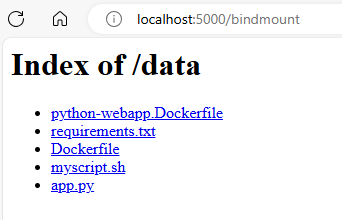

### Bind Mounts during build

Bind mounts can be used within Dockerfile to mount files and use them without copying them into the container image. In our Dockerfile we COPY the requirements.txt. Instead we can make the following changes to `python-webapp.Dockerfile`:

```dockerfile
# remove the following line
COPY requirements.txt requirements.txt

# Modify the RUN pip install line
RUN --mount=type=bind,source=requirements.txt,target=requirements.txt pip install -r requirements.txt
```

Run the build again with

```bash
docker build -t pythonapp:latest -f python-webapp.Dockerfile .
```

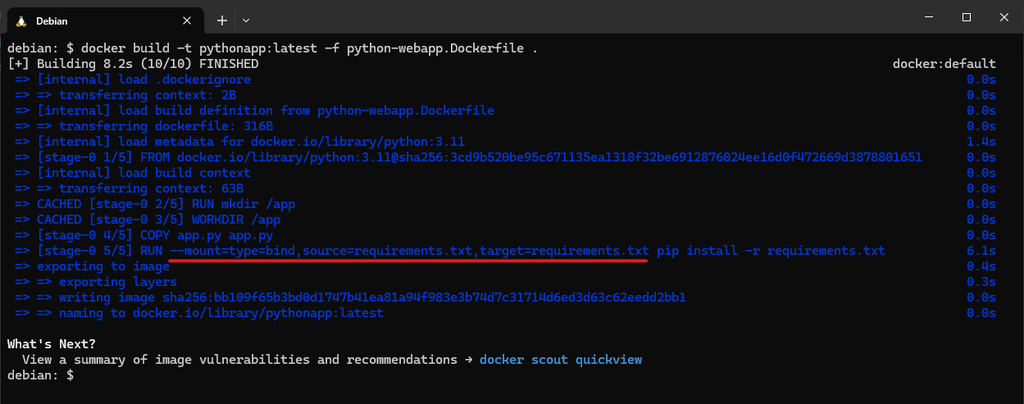

To verify this, we need to start a container and execute bash. Currently the `ENTRYPOINT` is a flask app. This can be changed with `docker run --entrypoint <script>` argument. Execute the following:

```bash
docker run --entrypoint bash -it pythonapp:latest
```

`-i` option makes the session interactive and `-t` option attaches the tty device (teletypewriter i.e. your console) for user inputs and feedback.

then once the container's prompt is available execute the following to list the files within the current directory:

```bash
ls -al
```

List all files in a vertical list. This should list only `app.py` and `requirements.txt` should be missing. Once verified execute `exit` to exit from the container's bash shell and return to your host's shell.

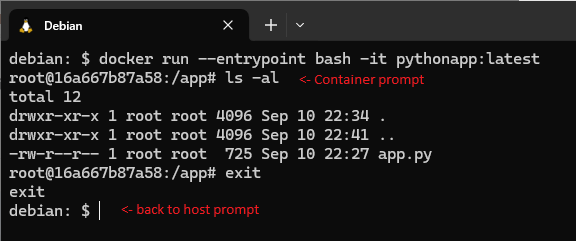

## Volumes

Volumes as entities can be managed separately from containers and images and have their own lifecycle. Create a volume, list and inspect it using:

```bash
$ docker volume create myvol
myvol
$ docker volume ls
DRIVER    VOLUME NAME
local     myvol
$ docker volume inspect myvol
[
    {
        "CreatedAt": "2024-09-10T22:46:56Z",
        "Driver": "local",
        "Labels": null,
        "Mountpoint": "/var/lib/docker/volumes/myvol/_data",
        "Name": "myvol",
        "Options": null,
        "Scope": "local"
    }
]
```

To mount this volume on a container we can use `-v` flag again. 

```bash
docker run -v myvol:/data:rw --entrypoint bash -it pythonapp:latest
```

Then verify it is empty by listing the `/data` dir within the container:

```bash
ls -al /data
```

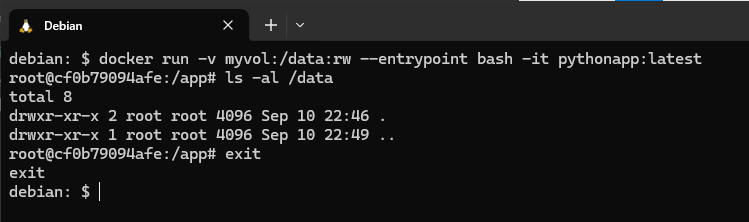

To populate this volume from the container, run the container and mount this volume to `/app`. This should copy the contents (app.py) to the volume. We can then remount the volume to `/data` and verify the contents. We will add `--rm` option to `docker run` to ensure the container is deleted after every use.

```bash
docker run --rm -v myvol:/app:rw --entrypoint bash -it pythonapp:latest
# Inside container prompt:
ls -al /app
exit
# host prompt:
docker run --rm -v myvol:/data:rw --entrypoint bash -it pythonapp:latest
# inside container prompt:
ls -al /data
exit
```

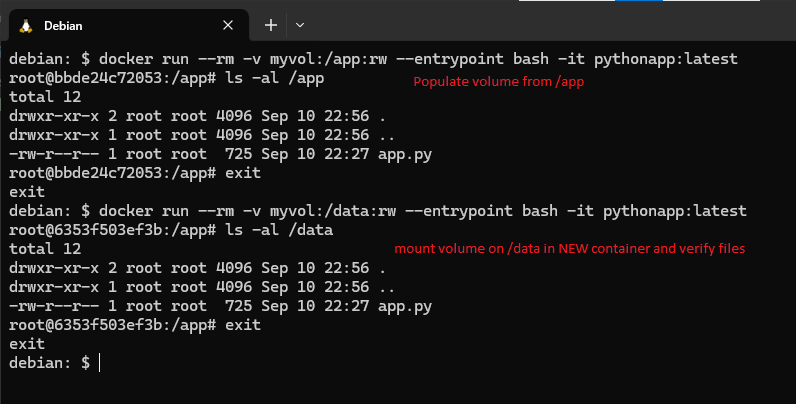

While the docker containers have been deleted, the volume persists. Volume can be deleted using 

```bash
docker volume rm myvol
```

You will likely get an error like `Error response from daemon: remove myvol: volume is in use - [cf0b79094afe4d42345cfbca50f2f2eae01687480a104f413e23d3f7370e84b4]`. It means that the volume is still attached to a container with the specified ID. You can find the container state using `docker ps -a`. If it is stopped, remove the container with `docker container rm <id>`. Then try removing the volume again.